In [1]:
import pandas as pd
import json
import pyarrow as pa
import pyarrow.parquet as pq
import requests
import pendulum
import sys
import os
import re
import matplotlib.pyplot as plt 
import seaborn as sns
import psycopg2


In [5]:
print(pendulum.yesterday("Europe/Paris"))

2026-02-04 00:00:00+01:00


In [2]:
url = ("https://raw.githubusercontent.com/mhollingshead/billboard-hot-100/main/recent.json")
query_parameters = {"downloadformat": "csv"}
response = requests.get(url, params=query_parameters)


In [3]:
response.content

b'{"date":"2026-01-17","data":[{"song":"The Fate Of Ophelia","artist":"Taylor Swift","this_week":1,"last_week":1,"peak_position":1,"weeks_on_chart":14},{"song":"Ordinary","artist":"Alex Warren","this_week":2,"last_week":3,"peak_position":1,"weeks_on_chart":47},{"song":"Golden","artist":"HUNTR/X: EJAE, Audrey Nuna & REI AMI","this_week":3,"last_week":2,"peak_position":1,"weeks_on_chart":29},{"song":"Man I Need","artist":"Olivia Dean","this_week":4,"last_week":4,"peak_position":4,"weeks_on_chart":20},{"song":"Choosin\' Texas","artist":"Ella Langley","this_week":5,"last_week":5,"peak_position":5,"weeks_on_chart":12},{"song":"End Of Beginning","artist":"Djo","this_week":6,"last_week":16,"peak_position":6,"weeks_on_chart":23},{"song":"Folded","artist":"Kehlani","this_week":7,"last_week":6,"peak_position":6,"weeks_on_chart":30},{"song":"Back To Friends","artist":"sombr","this_week":8,"last_week":7,"peak_position":7,"weeks_on_chart":41},{"song":"Opalite","artist":"Taylor Swift","this_week":9,

In [4]:
data = json.loads(response.content)
s = json.dumps(data, indent=4, sort_keys=True)
file3 = pd.read_json(s)

/tmp/ipykernel_570/1196471522.py:3: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  file3 = pd.read_json(s)


In [5]:
display(pd.json_normalize(file3['data']))

,artist,last_week,peak_position,song,this_week,weeks_on_chart
0,Taylor Swift,1.0,1,The Fate Of Ophelia,1,14
1,Alex Warren,3.0,1,Ordinary,2,47
2,"HUNTR/X: EJAE, Audrey Nuna & REI AMI",2.0,1,Golden,3,29
3,Olivia Dean,4.0,4,Man I Need,4,20
4,Ella Langley,5.0,5,Choosin' Texas,5,12
...,...,...,...,...,...,...
95,Ty Dolla $ign Featuring Quavo & Juicy J,NaN,96,Don't Kill The Party,96,1
96,Jelly Roll,84.0,53,Heart Of Stone,97,15
97,Josiah Queen,NaN,92,Dusty Bibles,98,2
98,Olivia Dean,NaN,99,I've Seen It,99,1


In [6]:
file_merged = pd.concat([file3['date'], pd.json_normalize(file3['data'])], axis=1)

In [7]:
file_merged = file_merged.iloc[:, [0,4,1,2,3,5]]
['','','','','','','']
file_merged

,date,song,artist,last_week,peak_position,this_week
0,2026-01-17,The Fate Of Ophelia,Taylor Swift,1.0,1,1
1,2026-01-17,Ordinary,Alex Warren,3.0,1,2
2,2026-01-17,Golden,"HUNTR/X: EJAE, Audrey Nuna & REI AMI",2.0,1,3
3,2026-01-17,Man I Need,Olivia Dean,4.0,4,4
4,2026-01-17,Choosin' Texas,Ella Langley,5.0,5,5
...,...,...,...,...,...,...
95,2026-01-17,Don't Kill The Party,Ty Dolla $ign Featuring Quavo & Juicy J,NaN,96,96
96,2026-01-17,Heart Of Stone,Jelly Roll,84.0,53,97
97,2026-01-17,Dusty Bibles,Josiah Queen,NaN,92,98
98,2026-01-17,I've Seen It,Olivia Dean,NaN,99,99


In [8]:
billboardOAT = pd.read_parquet('raw/billboard/billboard_100_OAT.parquet', engine='pyarrow')

In [9]:
billboardOAT

,date,song,artist,this_week,last_week,peak_position,weeks_on_chart
0,1970-01-01,Poor Little Fool,Ricky Nelson,1.0,NaN,1.0,1.0
1,1970-01-01,Patricia,Perez Prado And His Orchestra,2.0,NaN,2.0,1.0
2,1970-01-01,Splish Splash,Bobby Darin,3.0,NaN,3.0,1.0
3,1970-01-01,Hard Headed Woman,Elvis Presley With The Jordanaires,4.0,NaN,4.0,1.0
4,1970-01-01,When,Kalin Twins,5.0,NaN,5.0,1.0
...,...,...,...,...,...,...,...
351495,1970-01-01,For Good,Cynthia Erivo & Ariana Grande,96.0,43.0,43.0,2.0
351496,1970-01-01,No Good Deed,Cynthia Erivo,97.0,56.0,56.0,2.0
351497,1970-01-01,Let Alone The One You Love,Olivia Dean,98.0,95.0,95.0,3.0
351498,1970-01-01,The Life Of A Showgirl,Taylor Swift Featuring Sabrina Carpenter,99.0,80.0,8.0,9.0


In [10]:
oat = pd.concat([billboardOAT, file_merged],ignore_index=True)
oat

,date,song,artist,this_week,last_week,peak_position,weeks_on_chart
0,1970-01-01,Poor Little Fool,Ricky Nelson,1.0,NaN,1.0,1.0
1,1970-01-01,Patricia,Perez Prado And His Orchestra,2.0,NaN,2.0,1.0
2,1970-01-01,Splish Splash,Bobby Darin,3.0,NaN,3.0,1.0
3,1970-01-01,Hard Headed Woman,Elvis Presley With The Jordanaires,4.0,NaN,4.0,1.0
4,1970-01-01,When,Kalin Twins,5.0,NaN,5.0,1.0
...,...,...,...,...,...,...,...
351595,2026-01-17 00:00:00,Don't Kill The Party,Ty Dolla $ign Featuring Quavo & Juicy J,96.0,NaN,96.0,NaN
351596,2026-01-17 00:00:00,Heart Of Stone,Jelly Roll,97.0,84.0,53.0,NaN
351597,2026-01-17 00:00:00,Dusty Bibles,Josiah Queen,98.0,NaN,92.0,NaN
351598,2026-01-17 00:00:00,I've Seen It,Olivia Dean,99.0,NaN,99.0,NaN


In [11]:
oat['date'] = pd.to_datetime(oat['date']).dt.date
oat

,date,song,artist,this_week,last_week,peak_position,weeks_on_chart
0,1970-01-01,Poor Little Fool,Ricky Nelson,1.0,NaN,1.0,1.0
1,1970-01-01,Patricia,Perez Prado And His Orchestra,2.0,NaN,2.0,1.0
2,1970-01-01,Splish Splash,Bobby Darin,3.0,NaN,3.0,1.0
3,1970-01-01,Hard Headed Woman,Elvis Presley With The Jordanaires,4.0,NaN,4.0,1.0
4,1970-01-01,When,Kalin Twins,5.0,NaN,5.0,1.0
...,...,...,...,...,...,...,...
351595,2026-01-17,Don't Kill The Party,Ty Dolla $ign Featuring Quavo & Juicy J,96.0,NaN,96.0,NaN
351596,2026-01-17,Heart Of Stone,Jelly Roll,97.0,84.0,53.0,NaN
351597,2026-01-17,Dusty Bibles,Josiah Queen,98.0,NaN,92.0,NaN
351598,2026-01-17,I've Seen It,Olivia Dean,99.0,NaN,99.0,NaN


# Partie Analyse et création dossier Spotify

In [20]:
file2

,artists,disc_number,duration_ms,explicit,href,id,is_local,is_playable,name,popularity,...,album.images,album.is_playable,album.name,album.release_date,album.release_date_precision,album.total_tracks,album.type,album.uri,external_ids.isrc,external_urls.spotify
0,[{'external_urls': {'spotify': 'https://open.s...,1,217627,False,https://api.spotify.com/v1/tracks/7MrdHOL2aoWf...,7MrdHOL2aoWfT16CncgNei,False,True,Monica,68,...,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",True,Coolie (Original Motion Picture Soundtrack),2025-08-02,day,8,album,spotify:album:3roEiD2gUP1LHPHwUPbXs1,QMDA62550185,https://open.spotify.com/track/7MrdHOL2aoWfT16...
1,[{'external_urls': {'spotify': 'https://open.s...,1,197104,False,https://api.spotify.com/v1/tracks/28keFvZn4UVR...,28keFvZn4UVRi4I8Rj4GjY,False,True,"Thalapathy Kacheri (From ""Jana Nayagan"")",76,...,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",True,"Thalapathy Kacheri (From ""Jana Nayagan"")",2025-11-08,day,1,album,spotify:album:0TthxobhZuRUVweIhTUwuc,INS182504154,https://open.spotify.com/track/28keFvZn4UVRi4I...
2,[{'external_urls': {'spotify': 'https://open.s...,1,206627,False,https://api.spotify.com/v1/tracks/3JC5Xx48KqzY...,3JC5Xx48KqzYYlbTr6weCv,False,True,Powerhouse,68,...,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",True,Coolie (Original Motion Picture Soundtrack),2025-08-02,day,8,album,spotify:album:3roEiD2gUP1LHPHwUPbXs1,QMDA62587043,https://open.spotify.com/track/3JC5Xx48KqzYYlb...
3,[{'external_urls': {'spotify': 'https://open.s...,1,200373,False,https://api.spotify.com/v1/tracks/3xMHXmedL5Rv...,3xMHXmedL5Rvfxmiar9Ryv,False,True,Chaleya,69,...,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",True,Jawan,2023-09-05,day,7,album,spotify:album:3WLJmMZUeDOuERFAk1Mxs6,INS182302348,https://open.spotify.com/track/3xMHXmedL5Rvfxm...
4,[{'external_urls': {'spotify': 'https://open.s...,1,222063,False,https://api.spotify.com/v1/tracks/1bxzr3JK05fM...,1bxzr3JK05fMTcweGAZUHp,False,True,"Chuttamalle (From ""Devara Part 1"")",74,...,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",True,"Chuttamalle (From ""Devara Part 1"")",2024-08-05,day,1,album,spotify:album:77bk7awXNSGEQkZTcTp2Gj,INS182402313,https://open.spotify.com/track/1bxzr3JK05fMTcw...
5,[{'external_urls': {'spotify': 'https://open.s...,1,188505,False,https://api.spotify.com/v1/tracks/7vKddq80IImH...,7vKddq80IImHdiz83ZU2zF,False,True,Monica,65,...,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",True,Coolie (Original Motion Picture Soundtrack),2025-08-12,day,8,album,spotify:album:22mwh2WQgpVT4j5CaNGWYl,QMDA62550221,https://open.spotify.com/track/7vKddq80IImHdiz...
6,[{'external_urls': {'spotify': 'https://open.s...,1,256945,False,https://api.spotify.com/v1/tracks/4KUQFOGTaHrg...,4KUQFOGTaHrggl3hfMoaAe,False,True,"Kannamma - From ""Ispade Rajavum Idhaya Raniyum""",67,...,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",True,"Kannamma (From ""Ispade Rajavum Idhaya Raniyum"")",2019-01-11,day,1,album,spotify:album:7bgFFKluLbu4PRIRzdink9,INT201901935,https://open.spotify.com/track/4KUQFOGTaHrggl3...
7,[{'external_urls': {'spotify': 'https://open.s...,1,235629,False,https://api.spotify.com/v1/tracks/3CA9CjRf7IU2...,3CA9CjRf7IU2Ukz3GuYInP,False,True,Manasilaayo,68,...,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",True,Vettaiyan (Original Motion Picture Soundtrack),2024-10-14,day,9,album,spotify:album:6Xw7XAQQwpsy9KfUnJTrHz,INS172409897,https://open.spotify.com/track/3CA9CjRf7IU2Ukz...
8,[{'external_urls': {'spotify': 'https://open.s...,1,240845,False,https://api.spotify.com/v1/tracks/2unhBSPWS4Cp...,2unhBSPWS4Cpn5EfIKbAxG,False,True,Thangapoovey,56,...,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",True,Madharaasi (Original Motion Picture Soundtrack),2025-08-27,day,9,album,spotify:album:7HUzJeQvFdJDWueJi6pofV,INT132500505,https://open.spotify.com/track/2unhBSPWS4Cpn5E...
9,[{'external_urls': {'spotify': 'https://open.s...,1,207219,False,https://api.spotify.com/v1/tracks/07dj2zpMixBX...,07dj2zpMixBXxQuwp

In [23]:
#raw/spotify/artist/
file = pd.read_json("top_tracks_Anirudh Ravichander_2025-12-04.json")
file2 = pd.json_normalize(file.tracks)
display(file2.iloc[:,0:10])


,artists,disc_number,duration_ms,explicit,href,id,is_local,is_playable,name,popularity
0,[{'external_urls': {'spotify': 'https://open.s...,1,217627,False,https://api.spotify.com/v1/tracks/7MrdHOL2aoWf...,7MrdHOL2aoWfT16CncgNei,False,True,Monica,68
1,[{'external_urls': {'spotify': 'https://open.s...,1,197104,False,https://api.spotify.com/v1/tracks/28keFvZn4UVR...,28keFvZn4UVRi4I8Rj4GjY,False,True,"Thalapathy Kacheri (From ""Jana Nayagan"")",76
2,[{'external_urls': {'spotify': 'https://open.s...,1,206627,False,https://api.spotify.com/v1/tracks/3JC5Xx48KqzY...,3JC5Xx48KqzYYlbTr6weCv,False,True,Powerhouse,68
3,[{'external_urls': {'spotify': 'https://open.s...,1,200373,False,https://api.spotify.com/v1/tracks/3xMHXmedL5Rv...,3xMHXmedL5Rvfxmiar9Ryv,False,True,Chaleya,69
4,[{'external_urls': {'spotify': 'https://open.s...,1,222063,False,https://api.spotify.com/v1/tracks/1bxzr3JK05fM...,1bxzr3JK05fMTcweGAZUHp,False,True,"Chuttamalle (From ""Devara Part 1"")",74
5,[{'external_urls': {'spotify': 'https://open.s...,1,188505,False,https://api.spotify.com/v1/tracks/7vKddq80IImH...,7vKddq80IImHdiz83ZU2zF,False,True,Monica,65
6,[{'external_urls': {'spotify': 'https://open.s...,1,256945,False,https://api.spotify.com/v1/tracks/4KUQFOGTaHrg...,4KUQFOGTaHrggl3hfMoaAe,False,True,"Kannamma - From ""Ispade Rajavum Idhaya Raniyum""",67
7,[{'external_urls': {'spotify': 'https://open.s...,1,235629,False,https://api.spotify.com/v1/tracks/3CA9CjRf7IU2...,3CA9CjRf7IU2Ukz3GuYInP,False,True,Manasilaayo,68
8,[{'external_urls': {'spotify': 'https://open.s...,1,240845,False,https://api.spotify.com/v1/tracks/2unhBSPWS4Cp...,2unhBSPWS4Cpn5EfIKbAxG,False,True,Thangapoovey,56
9,[{'external_urls': {'spotify': 'https://open.s...,1,207219,False,https://api.spotify.com/v1/tracks/07dj2zpMixBX...,07dj2zpMixBXxQuwp4erRD,False,True,Salambala,56


In [68]:
file2.explode("artists").artists[0].values

array([{'external_urls': {'spotify': 'https://open.spotify.com/artist/4zCH9qm4R2DADamUHMCa6O'}, 'href': 'https://api.spotify.com/v1/artists/4zCH9qm4R2DADamUHMCa6O', 'id': '4zCH9qm4R2DADamUHMCa6O', 'name': 'Anirudh Ravichander', 'type': 'artist', 'uri': 'spotify:artist:4zCH9qm4R2DADamUHMCa6O'},
       {'external_urls': {'spotify': 'https://open.spotify.com/artist/0nh5cRtt03SU6LhzhVC5fv'}, 'href': 'https://api.spotify.com/v1/artists/0nh5cRtt03SU6LhzhVC5fv', 'id': '0nh5cRtt03SU6LhzhVC5fv', 'name': 'Sublahshini', 'type': 'artist', 'uri': 'spotify:artist:0nh5cRtt03SU6LhzhVC5fv'},
       {'external_urls': {'spotify': 'https://open.spotify.com/artist/4b1WCDqAVVgxK7KozLkOqc'}, 'href': 'https://api.spotify.com/v1/artists/4b1WCDqAVVgxK7KozLkOqc', 'id': '4b1WCDqAVVgxK7KozLkOqc', 'name': 'Asal Kolaar', 'type': 'artist', 'uri': 'spotify:artist:4b1WCDqAVVgxK7KozLkOqc'}],
      dtype=object)

In [24]:
file2.iloc[:,10:19]

,preview_url,track_number,type,uri,album.album_type,album.artists,album.external_urls.spotify,album.href,album.id
0,None,5,track,spotify:track:7MrdHOL2aoWfT16CncgNei,album,[{'external_urls': {'spotify': 'https://open.s...,https://open.spotify.com/album/3roEiD2gUP1LHPH...,https://api.spotify.com/v1/albums/3roEiD2gUP1L...,3roEiD2gUP1LHPHwUPbXs1
1,None,1,track,spotify:track:28keFvZn4UVRi4I8Rj4GjY,single,[{'external_urls': {'spotify': 'https://open.s...,https://open.spotify.com/album/0TthxobhZuRUVwe...,https://api.spotify.com/v1/albums/0TthxobhZuRU...,0TthxobhZuRUVweIhTUwuc
2,None,7,track,spotify:track:3JC5Xx48KqzYYlbTr6weCv,album,[{'external_urls': {'spotify': 'https://open.s...,https://open.spotify.com/album/3roEiD2gUP1LHPH...,https://api.spotify.com/v1/albums/3roEiD2gUP1L...,3roEiD2gUP1LHPHwUPbXs1
3,None,2,track,spotify:track:3xMHXmedL5Rvfxmiar9Ryv,album,[{'external_urls': {'spotify': 'https://open.s...,https://open.spotify.com/album/3WLJmMZUeDOuERF...,https://api.spotify.com/v1/albums/3WLJmMZUeDOu...,3WLJmMZUeDOuERFAk1Mxs6
4,None,1,track,spotify:track:1bxzr3JK05fMTcweGAZUHp,single,[{'external_urls': {'spotify': 'https://open.s...,https://open.spotify.com/album/77bk7awXNSGEQkZ...,https://api.spotify.com/v1/albums/77bk7awXNSGE...,77bk7awXNSGEQkZTcTp2Gj
5,None,5,track,spotify:track:7vKddq80IImHdiz83ZU2zF,album,[{'external_urls': {'spotify': 'https://open.s...,https://open.spotify.com/album/22mwh2WQgpVT4j5...,https://api.spotify.com/v1/albums/22mwh2WQgpVT...,22mwh2WQgpVT4j5CaNGWYl
6,None,1,track,spotify:track:4KUQFOGTaHrggl3hfMoaAe,single,[{'external_urls': {'spotify': 'https://open.s...,https://open.spotify.com/album/7bgFFKluLbu4PRI...,https://api.spotify.com/v1/albums/7bgFFKluLbu4...,7bgFFKluLbu4PRIRzdink9
7,None,1,track,spotify:track:3CA9CjRf7IU2Ukz3GuYInP,album,[{'external_urls': {'spotify': 'https://open.s...,https://open.spotify.com/album/6Xw7XAQQwpsy9Kf...,https://api.spotify.com/v1/albums/6Xw7XAQQwpsy...,6Xw7XAQQwpsy9KfUnJTrHz
8,None,8,track,spotify:track:2unhBSPWS4Cpn5EfIKbAxG,album,[{'external_urls': {'spotify': 'https://open.s...,https://open.spotify.com/album/7HUzJeQvFdJDWue...,https://api.spotify.com/v1/albums/7HUzJeQvFdJD...,7HUzJeQvFdJDWueJi6pofV
9,None,1,track,spotify:track:07dj2zpMixBXxQuwp4erRD,album,[{'external_urls': {'spotify': 'https://open.s...,https://open.spotify.com/album/7HUzJeQvFdJDWue...,https://api.spotify.com/v1/albums/7HUzJeQvFdJD...,7HUzJeQvFdJDWueJi6pofV


In [14]:
file2.iloc[:,19:29]

,album.images,album.is_playable,album.name,album.release_date,album.release_date_precision,album.total_tracks,album.type,album.uri,external_ids.isrc,external_urls.spotify
0,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",True,Coolie (Original Motion Picture Soundtrack),2025-08-02,day,8,album,spotify:album:3roEiD2gUP1LHPHwUPbXs1,QMDA62550185,https://open.spotify.com/track/7MrdHOL2aoWfT16...
1,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",True,"Thalapathy Kacheri (From ""Jana Nayagan"")",2025-11-08,day,1,album,spotify:album:0TthxobhZuRUVweIhTUwuc,INS182504154,https://open.spotify.com/track/28keFvZn4UVRi4I...
2,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",True,Coolie (Original Motion Picture Soundtrack),2025-08-02,day,8,album,spotify:album:3roEiD2gUP1LHPHwUPbXs1,QMDA62587043,https://open.spotify.com/track/3JC5Xx48KqzYYlb...
3,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",True,Jawan,2023-09-05,day,7,album,spotify:album:3WLJmMZUeDOuERFAk1Mxs6,INS182302348,https://open.spotify.com/track/3xMHXmedL5Rvfxm...
4,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",True,"Chuttamalle (From ""Devara Part 1"")",2024-08-05,day,1,album,spotify:album:77bk7awXNSGEQkZTcTp2Gj,INS182402313,https://open.spotify.com/track/1bxzr3JK05fMTcw...
5,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",True,Coolie (Original Motion Picture Soundtrack),2025-08-12,day,8,album,spotify:album:22mwh2WQgpVT4j5CaNGWYl,QMDA62550221,https://open.spotify.com/track/7vKddq80IImHdiz...
6,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",True,"Kannamma (From ""Ispade Rajavum Idhaya Raniyum"")",2019-01-11,day,1,album,spotify:album:7bgFFKluLbu4PRIRzdink9,INT201901935,https://open.spotify.com/track/4KUQFOGTaHrggl3...
7,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",True,Vettaiyan (Original Motion Picture Soundtrack),2024-10-14,day,9,album,spotify:album:6Xw7XAQQwpsy9KfUnJTrHz,INS172409897,https://open.spotify.com/track/3CA9CjRf7IU2Ukz...
8,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",True,Madharaasi (Original Motion Picture Soundtrack),2025-08-27,day,9,album,spotify:album:7HUzJeQvFdJDWueJi6pofV,INT132500505,https://open.spotify.com/track/2unhBSPWS4Cpn5E...
9,"[{'height': 640, 'url': 'https://i.scdn.co/ima...",True,Madharaasi (Original Motion Picture Soundtrack),2025-08-27,day,9,album,spotify:album:7HUzJeQvFdJDWueJi6pofV,INT132500431,https://open.spotify.com/track/07dj2zpMixBXxQu...


In [15]:
pd.json_normalize(file2.artists[0])['external_urls.spotify'].values


array(['https://open.spotify.com/artist/4zCH9qm4R2DADamUHMCa6O',
       'https://open.spotify.com/artist/0nh5cRtt03SU6LhzhVC5fv',
       'https://open.spotify.com/artist/4b1WCDqAVVgxK7KozLkOqc'],
      dtype=object)

In [16]:
pd.json_normalize(file2.artists[1])

,href,id,name,type,uri,external_urls.spotify
0,https://api.spotify.com/v1/artists/4zCH9qm4R2D...,4zCH9qm4R2DADamUHMCa6O,Anirudh Ravichander,artist,spotify:artist:4zCH9qm4R2DADamUHMCa6O,https://open.spotify.com/artist/4zCH9qm4R2DADa...
1,https://api.spotify.com/v1/artists/0fhunuOz2Ou...,0fhunuOz2OuOEr3YK5ctSm,Thalapathy Vijay,artist,spotify:artist:0fhunuOz2OuOEr3YK5ctSm,https://open.spotify.com/artist/0fhunuOz2OuOEr...
2,https://api.spotify.com/v1/artists/7rVV9d6vc4F...,7rVV9d6vc4FLT752uRuk71,Arivu,artist,spotify:artist:7rVV9d6vc4FLT752uRuk71,https://open.spotify.com/artist/7rVV9d6vc4FLT7...


In [17]:
file2["href"].values

array(['https://api.spotify.com/v1/tracks/7MrdHOL2aoWfT16CncgNei',
       'https://api.spotify.com/v1/tracks/28keFvZn4UVRi4I8Rj4GjY',
       'https://api.spotify.com/v1/tracks/3JC5Xx48KqzYYlbTr6weCv',
       'https://api.spotify.com/v1/tracks/3xMHXmedL5Rvfxmiar9Ryv',
       'https://api.spotify.com/v1/tracks/1bxzr3JK05fMTcweGAZUHp',
       'https://api.spotify.com/v1/tracks/7vKddq80IImHdiz83ZU2zF',
       'https://api.spotify.com/v1/tracks/4KUQFOGTaHrggl3hfMoaAe',
       'https://api.spotify.com/v1/tracks/3CA9CjRf7IU2Ukz3GuYInP',
       'https://api.spotify.com/v1/tracks/2unhBSPWS4Cpn5EfIKbAxG',
       'https://api.spotify.com/v1/tracks/07dj2zpMixBXxQuwp4erRD'],
      dtype=object)

In [18]:
pd.json_normalize(file2.artists[1])

,href,id,name,type,uri,external_urls.spotify
0,https://api.spotify.com/v1/artists/4zCH9qm4R2D...,4zCH9qm4R2DADamUHMCa6O,Anirudh Ravichander,artist,spotify:artist:4zCH9qm4R2DADamUHMCa6O,https://open.spotify.com/artist/4zCH9qm4R2DADa...
1,https://api.spotify.com/v1/artists/0fhunuOz2Ou...,0fhunuOz2OuOEr3YK5ctSm,Thalapathy Vijay,artist,spotify:artist:0fhunuOz2OuOEr3YK5ctSm,https://open.spotify.com/artist/0fhunuOz2OuOEr...
2,https://api.spotify.com/v1/artists/7rVV9d6vc4F...,7rVV9d6vc4FLT752uRuk71,Arivu,artist,spotify:artist:7rVV9d6vc4FLT752uRuk71,https://open.spotify.com/artist/7rVV9d6vc4FLT7...


In [19]:
pd.json_normalize(file2['album.images'])

,0,1,2
0,"{'height': 640, 'url': 'https://i.scdn.co/imag...","{'height': 300, 'url': 'https://i.scdn.co/imag...","{'height': 64, 'url': 'https://i.scdn.co/image..."
1,"{'height': 640, 'url': 'https://i.scdn.co/imag...","{'height': 300, 'url': 'https://i.scdn.co/imag...","{'height': 64, 'url': 'https://i.scdn.co/image..."
2,"{'height': 640, 'url': 'https://i.scdn.co/imag...","{'height': 300, 'url': 'https://i.scdn.co/imag...","{'height': 64, 'url': 'https://i.scdn.co/image..."
3,"{'height': 640, 'url': 'https://i.scdn.co/imag...","{'height': 300, 'url': 'https://i.scdn.co/imag...","{'height': 64, 'url': 'https://i.scdn.co/image..."
4,"{'height': 640, 'url': 'https://i.scdn.co/imag...","{'height': 300, 'url': 'https://i.scdn.co/imag...","{'height': 64, 'url': 'https://i.scdn.co/image..."
5,"{'height': 640, 'url': 'https://i.scdn.co/imag...","{'height': 300, 'url': 'https://i.scdn.co/imag...","{'height': 64, 'url': 'https://i.scdn.co/image..."
6,"{'height': 640, 'url': 'https://i.scdn.co/imag...","{'height': 300, 'url': 'https://i.scdn.co/imag...","{'height': 64, 'url': 'https://i.scdn.co/image..."
7,"{'height': 640, 'url': 'https://i.scdn.co/imag...","{'height': 300, 'url': 'https://i.scdn.co/imag...","{'height': 64, 'url': 'https://i.scdn.co/image..."
8,"{'height': 640, 'url': 'https://i.scdn.co/imag...","{'height': 300, 'url': 'https://i.scdn.co/imag...","{'height': 64, 'url': 'https://i.scdn.co/image..."
9,"{'height': 640, 'url': 'https://i.scdn.co/imag...","{'height': 300, 'url': 'https://i.scdn.co/imag...","{'height': 64, 'url': 'https://i.scdn.co/image..."


In [20]:
pd.json_normalize(pd.json_normalize(file2['album.images'])[0]).values


array([[640,
        'https://i.scdn.co/image/ab67616d0000b273ce3eecb6ce4eb1dfb6e06399',
        640],
       [640,
        'https://i.scdn.co/image/ab67616d0000b273e2b41d0e6e8205e913701a42',
        640],
       [640,
        'https://i.scdn.co/image/ab67616d0000b273ce3eecb6ce4eb1dfb6e06399',
        640],
       [640,
        'https://i.scdn.co/image/ab67616d0000b273e452a6e11147f3e56aee6f5b',
        640],
       [640,
        'https://i.scdn.co/image/ab67616d0000b2736d97b3dc154dfdbe2321fb5c',
        640],
       [640,
        'https://i.scdn.co/image/ab67616d0000b27372ecc7fb602ba81a006069b4',
        640],
       [640,
        'https://i.scdn.co/image/ab67616d0000b27378a66d1b99fce4ec68669654',
        640],
       [640,
        'https://i.scdn.co/image/ab67616d0000b2735648e0e2e38c0f9b6289ca40',
        640],
       [640,
        'https://i.scdn.co/image/ab67616d0000b2735689444cf34dffe6cdcffcee',
        640],
       [640,
        'https://i.scdn.co/image/ab67616d0000b2735689444cf34

In [21]:
pd.json_normalize(file2['album.images'][1])

,height,url,width
0,640,https://i.scdn.co/image/ab67616d0000b273e2b41d...,640
1,300,https://i.scdn.co/image/ab67616d00001e02e2b41d...,300
2,64,https://i.scdn.co/image/ab67616d00004851e2b41d...,64


In [20]:
data = pd.read_json('raw/spotify/artist/2026-01-28_top_tracks_Anirudh_Ravichander.json')
#data = pd.read_json('raw/spotify/artist/2026-01-28_top_tracks_HUNTRX.json')


In [21]:
display(pd.json_normalize(pd.json_normalize(data.tracks).artists)[0][0])
#display(pd.json_normalize(data.tracks).duration_ms)
columns = ["artists.id", "artists.name", "id", "name", "popularity", "duration_ms"]
new_dataset = pd.json_normalize(data.tracks)[["id", "name", "popularity", "duration_ms"]]
display(new_dataset)

# Il reste à récupérer les artistes ID et les artistes name dans les datasets



{'href': 'https://api.spotify.com/v1/artists/2yNNYQBChuox9A5Ka93BIn',
 'id': '2yNNYQBChuox9A5Ka93BIn',
 'name': 'HUNTR/X',
 'type': 'artist',
 'uri': 'spotify:artist:2yNNYQBChuox9A5Ka93BIn',
 'external_urls.spotify': 'https://open.spotify.com/artist/2yNNYQBChuox9A5Ka93BIn'}

,id,name,popularity,duration_ms
0,1CPZ5BxNNd0n0nF4Orb9JS,Golden,97,194607
1,5sBDrrtLGbV64QJnEqfjer,What It Sounds Like,88,250268
2,3RXUgPNIbUgFxsDWuBQEt6,How It’s Done,88,176059
3,0MHStU0muAIEMbwdnebYu2,Takedown,87,182016
4,5tVnzVWIKrmmuOPGbXUbT4,Golden - David Guetta REM/X,76,176250
5,03x2Hzommc7gHp1rqh0xBC,Dorada - Golden - versión en español,73,192974
6,4Zg2p0S5G6dxF3xCmRBv3R,Briller - Golden - version française,71,192974
7,3RUVLIRUNA3KHLt8pd8PL6,Golden - Acapella,67,192974
8,3p3FbElRZudNO4hp1Av8MO,Golden - David Guetta REM/X (Extended),65,235000
9,5LByxLn1X1Q9vr0xa4ZLYf,Golden - Instrumental,65,192974


In [40]:
display(pd.json_normalize(pd.json_normalize(data.tracks).artists).shape)
artists = pd.json_normalize(pd.json_normalize(data.tracks).artists)
number_of_tracks = artists.shape[0]
number_max_of_artists = artists.shape[1]
print(number_of_tracks)
print(number_max_of_artists)
lists_artists = {}
for i in range(number_of_tracks):
    compteur = 0
    for j in range(number_max_of_artists):
        if artists[j][i] == None:
            break
        compteur+=1
    for h in range(compteur):
        lists_artists.append(artists[h][i]['name'])
print(lists_artists)
        


(10, 6)

10
6
['HUNTR/X', 'EJAE', 'AUDREY NUNA', 'REI AMI', 'KPop Demon Hunters Cast', 'HUNTR/X', 'EJAE', 'AUDREY NUNA', 'REI AMI', 'KPop Demon Hunters Cast', 'HUNTR/X', 'EJAE', 'AUDREY NUNA', 'REI AMI', 'KPop Demon Hunters Cast', 'HUNTR/X', 'EJAE', 'AUDREY NUNA', 'REI AMI', 'KPop Demon Hunters Cast', 'HUNTR/X', 'EJAE', 'AUDREY NUNA', 'REI AMI', 'KPop Demon Hunters Cast', 'David Guetta', 'HUNTR/X', 'Azul Botticher', 'Karin Zavala', 'Tatul Bernodat', 'KPop Demon Hunters Cast', 'HUNTR/X', 'Alexiane Broque', 'Jeanne Jérosme', 'Clotilde Verry', 'KPop Demon Hunters Cast', 'HUNTR/X', 'EJAE', 'AUDREY NUNA', 'REI AMI', 'KPop Demon Hunters Cast', 'HUNTR/X', 'EJAE', 'AUDREY NUNA', 'REI AMI', 'KPop Demon Hunters Cast', 'David Guetta', 'HUNTR/X', 'KPop Demon Hunters Cast']


In [45]:
print(pd.json_normalize(pd.json_normalize(data.tracks).artists)[0][0])

{'href': 'https://api.spotify.com/v1/artists/2yNNYQBChuox9A5Ka93BIn', 'id': '2yNNYQBChuox9A5Ka93BIn', 'name': 'HUNTR/X', 'type': 'artist', 'uri': 'spotify:artist:2yNNYQBChuox9A5Ka93BIn', 'external_urls.spotify': 'https://open.spotify.com/artist/2yNNYQBChuox9A5Ka93BIn'}


In [2]:
print(os.getcwd())
os.chdir('/home/kesav/airflow_project/raw/spotify/artist')

with os.scandir(".") as d:
    for e in d:
        print(e.name)

/home/kesav/airflow_project
2025-12-19_top_tracks_Kendrick_Lamar.json
2026-01-28_top_tracks_Sabrina_Carpenter.json
2026-02-05_top_tracks_HUNTRX.json
2026-02-05_top_tracks_Bruno_Mars.json
top_tracks_Bruno_Mars_2025-12-15.json
2025-12-19_top_tracks_The_Weekend.json
2026-02-05_top_tracks_The_Weekend.json
top_tracks_Taylor Swift_2025-12-04.json
2026-01-28_top_tracks_Fuerza_Regida.json
2026-02-05_top_tracks_Drake.json
2026-02-18_top_tracks_Arijit_Singh.json
2026-02-18_top_tracks_Drake.json
2026-04-15_top_tracks_Billie_Eilish.json
top_tracks_Kendrick_Lamar_2025-12-15.json
top_tracks_Billie_Eilish_2025-12-15.json
top_tracks_Kendrick Lamar_2025-12-04.json
top_tracks_Bad_Bunny_2025-12-15.json
top_tracks_Anirudh_Ravichander_2025-12-15.json
2026-02-18_top_tracks_Bruno_Mars.json
2026-01-28_top_tracks_Arijit_Singh.json
2026-02-18_top_tracks_Billie_Eilish.json
2026-01-28_top_tracks_Bruno_Mars.json
top_tracks_Bruno Mars_2025-12-04.json
2026-04-15_top_tracks_Sabrina_Carpenter.json
2026-01-28_top_track

In [3]:
# On affiche le chemin
print(os.getcwd())
# On change le répertoire en cours
os.chdir('/home/kesav/airflow_project/raw/spotify/artist')
# On affiche le chemin pour vérifier le changement
print(os.getcwd())
# On crée une liste vide
name_file_to_analyze = []
# On récupère tous les fichiers qui contiennent 2026 dans le répertoire Spotify
with os.scandir(".") as d:
    for e in d:
        if "2026-04-15" in e.name:
            name_file_to_analyze.append(e.name)
# On affiche notre nouvelle liste avec tous les noms qui nous intéressent
for i in name_file_to_analyze:
    print(i)
""" 
Ce qu'il reste à faire, c'est de parcourir les fichiers pour les stocker dans une liste et récupérer une liste de nos files sous forme de json pandas
"""


/home/kesav/airflow_project/raw/spotify/artist
/home/kesav/airflow_project/raw/spotify/artist
2026-04-15_top_tracks_Billie_Eilish.json
2026-04-15_top_tracks_Sabrina_Carpenter.json
2026-04-15_top_tracks_Ariana_Grande.json
2026-04-15_top_tracks_Bad_Bunny.json
2026-04-15_top_tracks_Arijit_Singh.json
2026-04-15_top_tracks_Bruno_Mars.json
2026-04-15_top_tracks_Anirudh_Ravichander.json
2026-04-15_top_tracks_Kendrick_Lamar.json
2026-04-15_top_tracks_Taylor_Swift.json
2026-04-15_top_tracks_HUNTRX.json
2026-04-15_top_tracks_Drake.json
2026-04-15_top_tracks_The_Weekend.json
2026-04-15_top_tracks_Fuerza_Regida.json
2026-04-15_top_tracks_Billie_Eilish.json
2026-04-15_top_tracks_Sabrina_Carpenter.json
2026-04-15_top_tracks_Ariana_Grande.json
2026-04-15_top_tracks_Bad_Bunny.json
2026-04-15_top_tracks_Arijit_Singh.json
2026-04-15_top_tracks_Bruno_Mars.json
2026-04-15_top_tracks_Anirudh_Ravichander.json
2026-04-15_top_tracks_Kendrick_Lamar.json
2026-04-15_top_tracks_Taylor_Swift.json
2026-04-15_top_tr

" \nCe qu'il reste à faire, c'est de parcourir les fichiers pour les stocker dans une liste et récupérer une liste de nos files sous forme de json pandas\n"

In [81]:
gather_tracks = ""

""" for i in name_file_to_analyze:
    f = open(f'/home/kesav/airflow_project/raw/spotify/artist/{i}')
    gather_tracks = gather_tracks + f.read()
    #gather_tracks = pd.concat([gather_tracks,pd.read_json() """

dico_artists = {"Bad_Bunny": "4q3ewBCX7sLwd24euuV69X",
                    "Taylor_Swift" : "06HL4z0CvFAxyc27GXpf02",
                    "The_Weekend" : "1Xyo4u8uXC1ZmMpatF05PJ",
                    "Drake" : "3TVXtAsR1Inumwj472S9r4",
                    "Billie_Eilish" : "6qqNVTkY8uBg9cP3Jd7DAH",
                    "Kendrick_Lamar" : "2YZyLoL8N0Wb9xBt1NhZWg",
                    "Bruno_Mars" : "0du5cEVh5yTK9QJze8zA0C",
                    "Ariana_Grande" : "66CXWjxzNUsdJxJ2JdwvnR",
                    "Arijit_Singh" : "4YRxDV8wJFPHPTeXepOstw",
                    "Fuerza_Regida" : "0ys2OFYzWYB5hRDLCsBqxt",
                    "Anirudh_Ravichander" : "4zCH9qm4R2DADamUHMCa6O",
                    "Sabrina_Carpenter" : "74KM79TiuVKeVCqs8QtB0B",
                    "Kendrick_Lamar" : "2YZyLoL8N0Wb9xBt1NhZWg",
                    "HUNTRX" : "2yNNYQBChuox9A5Ka93BIn"
                    }


gather_tracks_2 = pd.DataFrame()
for i in name_file_to_analyze:
    # On va lire le ficheir de l'artiste avec la date concernée
    f = pd.read_json(f'/home/kesav/airflow_project/raw/spotify/artist/{i}')
    # On normalise le fichier pour récupérer tout au format colonne
    tracks = pd.json_normalize(f.tracks)
    # On utilise le Regex pour sélectionner la partie spécifique de texte dont on a besoin (ie. nom de l'artiste)
    x = re.findall(r"s_(.+).json$", i)
    # On ajoute une colonne avec le nom de l'artiste
    tracks["artist.name"] = x[0]
    # On ajoute un colonne avec l'id de l'artiste
    tracks["artist.id"] = dico_artists[x[0]]
    # On sélectionne les colonnes dont on a besoin
    columns = ["artist.name", "artist.id", "id", "name", "popularity", "duration_ms"]
    # On concatène le dataframe dans notre dataframe principal
    gather_tracks_2 = pd.concat([gather_tracks_2, tracks[columns]])







In [78]:
dico_artists = {"Bad_Bunny": "4q3ewBCX7sLwd24euuV69X",
                    "Taylor_Swift" : "06HL4z0CvFAxyc27GXpf02",
                    "The_Weekend" : "1Xyo4u8uXC1ZmMpatF05PJ",
                    "Drake" : "3TVXtAsR1Inumwj472S9r4",
                    "Billie_Eilish" : "6qqNVTkY8uBg9cP3Jd7DAH",
                    "Kendrick_Lamar" : "2YZyLoL8N0Wb9xBt1NhZWg",
                    "Bruno_Mars" : "0du5cEVh5yTK9QJze8zA0C",
                    "Ariana_Grande" : "66CXWjxzNUsdJxJ2JdwvnR",
                    "Arijit_Singh" : "4YRxDV8wJFPHPTeXepOstw",
                    "Fuerza_Regida" : "0ys2OFYzWYB5hRDLCsBqxt",
                    "Anirudh_Ravichander" : "4zCH9qm4R2DADamUHMCa6O",
                    "Sabrina_Carpenter" : "74KM79TiuVKeVCqs8QtB0B",
                    "Kendrick_Lamar" : "2YZyLoL8N0Wb9xBt1NhZWg",
                    "HUNTRX" : "2yNNYQBChuox9A5Ka93BIn"
                    }
print(dico_artists["Bad_Bunny"])

i = "2026-04-15_top_tracks_Fuerza_Regida.json"
print(i.strip('2026-04-15_top_tracks_').strip(".json"))
print(re.sub(r"s_(.+).json$", '', i))
x = re.findall(r"s_(.+).json$", i)
print(x[0])


4q3ewBCX7sLwd24euuV69X
Fuerza_Regida
2026-04-15_top_track
Fuerza_Regida


In [82]:
gather_tracks_2

,artist.name,artist.id,id,name,popularity,duration_ms
0,Billie_Eilish,6qqNVTkY8uBg9cP3Jd7DAH,6dOtVTDdiauQNBQEDOtlAB,BIRDS OF A FEATHER,95,210373
1,Billie_Eilish,6qqNVTkY8uBg9cP3Jd7DAH,3QaPy1KgI7nu9FJEQUgn6h,WILDFLOWER,93,261466
2,Billie_Eilish,6qqNVTkY8uBg9cP3Jd7DAH,0u2P5u6lvoDfwTYjAADbn4,lovely (with Khalid),89,200185
3,Billie_Eilish,6qqNVTkY8uBg9cP3Jd7DAH,2uIX8YMNjGMD7441kqyyNU,ocean eyes,85,200560
4,Billie_Eilish,6qqNVTkY8uBg9cP3Jd7DAH,7BRD7x5pt8Lqa1eGYC4dzj,CHIHIRO,87,303440
...,...,...,...,...,...,...
5,Fuerza_Regida,0ys2OFYzWYB5hRDLCsBqxt,5mp6OBKCAjN4UYRvhOuUze,Tu Boda,79,225880
6,Fuerza_Regida,0ys2OFYzWYB5hRDLCsBqxt,3D24ErT1MMmUfXWotSj2A2,ME JALO,86,212002
7,Fuerza_Regida,0ys2OFYzWYB5hRDLCsBqxt,3qdeRGn9erK9sjs1kUtBys,CHAVALITAS,86,164482
8,Fuerza_Regida,0ys2OFYzWYB5hRDLCsBqxt,6272S5nkbOvQDazRYq6muV,caperuza,85,179317


In [83]:
gather_tracks_2.reset_index(drop=True)

,artist.name,artist.id,id,name,popularity,duration_ms
0,Billie_Eilish,6qqNVTkY8uBg9cP3Jd7DAH,6dOtVTDdiauQNBQEDOtlAB,BIRDS OF A FEATHER,95,210373
1,Billie_Eilish,6qqNVTkY8uBg9cP3Jd7DAH,3QaPy1KgI7nu9FJEQUgn6h,WILDFLOWER,93,261466
2,Billie_Eilish,6qqNVTkY8uBg9cP3Jd7DAH,0u2P5u6lvoDfwTYjAADbn4,lovely (with Khalid),89,200185
3,Billie_Eilish,6qqNVTkY8uBg9cP3Jd7DAH,2uIX8YMNjGMD7441kqyyNU,ocean eyes,85,200560
4,Billie_Eilish,6qqNVTkY8uBg9cP3Jd7DAH,7BRD7x5pt8Lqa1eGYC4dzj,CHIHIRO,87,303440
...,...,...,...,...,...,...
125,Fuerza_Regida,0ys2OFYzWYB5hRDLCsBqxt,5mp6OBKCAjN4UYRvhOuUze,Tu Boda,79,225880
126,Fuerza_Regida,0ys2OFYzWYB5hRDLCsBqxt,3D24ErT1MMmUfXWotSj2A2,ME JALO,86,212002
127,Fuerza_Regida,0ys2OFYzWYB5hRDLCsBqxt,3qdeRGn9erK9sjs1kUtBys,CHAVALITAS,86,164482
128,Fuerza_Regida,0ys2OFYzWYB5hRDLCsBqxt,6272S5nkbOvQDazRYq6muV,caperuza,85,179317


In [1]:
import requests
import json
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq



def fetch_data():
    return pd.read_json("https://raw.githubusercontent.com/mhollingshead/billboard-hot-100/main/all.json")
    

def transform_data(file_new):
    new_dataset = pd.json_normalize(pd.melt(pd.json_normalize(file_new.data).transpose()).value)
    new_dataset['date'] = file_new['date'][0]
    k = 0
    for i in file_new['date']:
        for j in range(0,100):
            new_dataset.loc[k,'date'] = i
            k = k+1
    #new_dataset['date'] = pd.to_datetime(new_dataset['date']).dt.date
    return new_dataset.iloc[:, [6,0,1,2,3,4,5]]

def write_table(new_dataset):
    table = pa.Table.from_pandas(new_dataset)
    pq.write_table(table, 'raw/billboard/billboard_100_OAT.parquet')
    new_dataset.to_json('raw/billboard/billboard_100_OAT.json')
    new_dataset.to_csv('raw/billboard/billboard_100_OAT.csv', index=False)
        

"""def fetch_billboard_data():
    file_new = fetch_data()
    pd.json_normalize(pd.melt(pd.json_normalize(file_new.data).transpose()).value)
    new_dataset = transform_data(file_new)
    write_table(new_dataset)
    

if __name__ == "__main__":
   fetch_billboard_data() """

'def fetch_billboard_data():\n    file_new = fetch_data()\n    pd.json_normalize(pd.melt(pd.json_normalize(file_new.data).transpose()).value)\n    new_dataset = transform_data(file_new)\n    write_table(new_dataset)\n\n\nif __name__ == "__main__":\n   fetch_billboard_data() '

In [2]:
file_new = fetch_data()
#new_dataset = pd.json_normalize(pd.melt(pd.json_normalize(file_new.data).transpose()).value)


In [3]:
file_new

,date,data
0,1958-08-04,"[{'song': 'Poor Little Fool', 'artist': 'Ricky..."
1,1958-08-11,"[{'song': 'Poor Little Fool', 'artist': 'Ricky..."
2,1958-08-18,"[{'song': 'Nel Blu Dipinto Di Blu (Volare)', '..."
3,1958-08-25,"[{'song': 'Little Star', 'artist': 'The Elegan..."
4,1958-09-01,"[{'song': 'Nel Blu Dipinto Di Blu (Volare)', '..."
...,...,...
3518,2026-01-10,"[{'song': 'The Fate Of Ophelia', 'artist': 'Ta..."
3519,2026-01-17,"[{'song': 'The Fate Of Ophelia', 'artist': 'Ta..."
3520,2026-01-24,"[{'song': 'I Just Might', 'artist': 'Bruno Mar..."
3521,2026-01-31,"[{'song': 'I Just Might', 'artist': 'Bruno Mar..."


In [3]:
pd.melt(pd.json_normalize(file_new.data))

,variable,value
0,0,"{'song': 'Poor Little Fool', 'artist': 'Ricky ..."
1,0,"{'song': 'Poor Little Fool', 'artist': 'Ricky ..."
2,0,"{'song': 'Nel Blu Dipinto Di Blu (Volare)', 'a..."
3,0,"{'song': 'Little Star', 'artist': 'The Elegant..."
4,0,"{'song': 'Nel Blu Dipinto Di Blu (Volare)', 'a..."
...,...,...
352295,99,"{'song': 'Voy A Llevarte Pa PR', 'artist': 'Ba..."
352296,99,"{'song': 'Stateside', 'artist': 'PinkPantheres..."
352297,99,"{'song': 'Big Guy', 'artist': 'Ice Spice', 'th..."
352298,99,"{'song': 'Sienna', 'artist': 'The Marias', 'th..."


In [8]:
df = pd.read_json("https://raw.githubusercontent.com/mhollingshead/billboard-hot-100/main/all.json")
display(df)




,date,data
0,1958-08-04,"[{'song': 'Poor Little Fool', 'artist': 'Ricky..."
1,1958-08-11,"[{'song': 'Poor Little Fool', 'artist': 'Ricky..."
2,1958-08-18,"[{'song': 'Nel Blu Dipinto Di Blu (Volare)', '..."
3,1958-08-25,"[{'song': 'Little Star', 'artist': 'The Elegan..."
4,1958-09-01,"[{'song': 'Nel Blu Dipinto Di Blu (Volare)', '..."
...,...,...
3528,2026-03-21,"[{'song': 'Choosin' Texas', 'artist': 'Ella La..."
3529,2026-03-28,"[{'song': 'Choosin' Texas', 'artist': 'Ella La..."
3530,2026-04-04,"[{'song': 'Swim', 'artist': 'BTS', 'this_week'..."
3531,2026-04-11,"[{'song': 'Choosin' Texas', 'artist': 'Ella La..."


In [9]:
# Expand the "data" column into rows
exploded = df.explode("data", ignore_index=True)
display(exploded)

,date,data
0,1958-08-04,"{'song': 'Poor Little Fool', 'artist': 'Ricky ..."
1,1958-08-04,"{'song': 'Patricia', 'artist': 'Perez Prado An..."
2,1958-08-04,"{'song': 'Splish Splash', 'artist': 'Bobby Dar..."
3,1958-08-04,"{'song': 'Hard Headed Woman', 'artist': 'Elvis..."
4,1958-08-04,"{'song': 'When', 'artist': 'Kalin Twins', 'thi..."
...,...,...
353282,2026-04-18,"{'song': 'Can't Sit Still', 'artist': 'Lainey ..."
353283,2026-04-18,"{'song': 'Secondhand', 'artist': 'Don Toliver ..."
353284,2026-04-18,"{'song': 'This A Must', 'artist': 'Ye', 'this_..."
353285,2026-04-18,"{'song': 'Say So', 'artist': 'Dan + Shay', 'th..."


In [10]:
# Normalize each dict inside "data"
normalized = pd.json_normalize(exploded["data"])
display(normalized)


,song,artist,this_week,last_week,peak_position,weeks_on_chart
0,Poor Little Fool,Ricky Nelson,1,NaN,1,1
1,Patricia,Perez Prado And His Orchestra,2,NaN,2,1
2,Splish Splash,Bobby Darin,3,NaN,3,1
3,Hard Headed Woman,Elvis Presley With The Jordanaires,4,NaN,4,1
4,When,Kalin Twins,5,NaN,5,1
...,...,...,...,...,...,...
353282,Can't Sit Still,Lainey Wilson,96,NaN,82,2
353283,Secondhand,Don Toliver Featuring Rema,97,NaN,29,9
353284,This A Must,Ye,98,51.0,51,2
353285,Say So,Dan + Shay,99,NaN,99,1


In [11]:
# Add the date column back (automatically aligned after explode)
normalized["date"] = exploded["date"]

display(normalized["date"])

0        1958-08-04
1        1958-08-04
2        1958-08-04
3        1958-08-04
4        1958-08-04
            ...    
353282   2026-04-18
353283   2026-04-18
353284   2026-04-18
353285   2026-04-18
353286   2026-04-18
Name: date, Length: 353287, dtype: datetime64[us]

In [13]:
display(col for col in normalized.columns if col != "date")

<generator object <genexpr> at 0x7f9578af0790>

In [14]:
normalized.columns

Index(['song', 'artist', 'this_week', 'last_week', 'peak_position',
       'weeks_on_chart', 'date'],
      dtype='str')

In [6]:
# Reorder columns
display(normalized[["date"] + [col for col in normalized.columns if col != "date"]])



,date,song,artist,this_week,last_week,peak_position,weeks_on_chart
0,1958-08-04,Poor Little Fool,Ricky Nelson,1,NaN,1,1
1,1958-08-04,Patricia,Perez Prado And His Orchestra,2,NaN,2,1
2,1958-08-04,Splish Splash,Bobby Darin,3,NaN,3,1
3,1958-08-04,Hard Headed Woman,Elvis Presley With The Jordanaires,4,NaN,4,1
4,1958-08-04,When,Kalin Twins,5,NaN,5,1
...,...,...,...,...,...,...,...
353282,2026-04-18,Can't Sit Still,Lainey Wilson,96,NaN,82,2
353283,2026-04-18,Secondhand,Don Toliver Featuring Rema,97,NaN,29,9
353284,2026-04-18,This A Must,Ye,98,51.0,51,2
353285,2026-04-18,Say So,Dan + Shay,99,NaN,99,1


# Analyse des top tracks

In [3]:
gather_tracks_2 = pd.read_csv("/home/kesav/airflow_project/raw/spotify/gather_tracks/top_tracks_spotify.csv")



In [4]:
display(gather_tracks_2)

,artist.name,artist.id,id,name,popularity,duration_ms
0,Billie_Eilish,6qqNVTkY8uBg9cP3Jd7DAH,6dOtVTDdiauQNBQEDOtlAB,BIRDS OF A FEATHER,95,210373
1,Billie_Eilish,6qqNVTkY8uBg9cP3Jd7DAH,3QaPy1KgI7nu9FJEQUgn6h,WILDFLOWER,93,261466
2,Billie_Eilish,6qqNVTkY8uBg9cP3Jd7DAH,0u2P5u6lvoDfwTYjAADbn4,lovely (with Khalid),89,200185
3,Billie_Eilish,6qqNVTkY8uBg9cP3Jd7DAH,2uIX8YMNjGMD7441kqyyNU,ocean eyes,85,200560
4,Billie_Eilish,6qqNVTkY8uBg9cP3Jd7DAH,7BRD7x5pt8Lqa1eGYC4dzj,CHIHIRO,87,303440
...,...,...,...,...,...,...
125,Fuerza_Regida,0ys2OFYzWYB5hRDLCsBqxt,5mp6OBKCAjN4UYRvhOuUze,Tu Boda,79,225880
126,Fuerza_Regida,0ys2OFYzWYB5hRDLCsBqxt,3D24ErT1MMmUfXWotSj2A2,ME JALO,86,212002
127,Fuerza_Regida,0ys2OFYzWYB5hRDLCsBqxt,3qdeRGn9erK9sjs1kUtBys,CHAVALITAS,86,164482
128,Fuerza_Regida,0ys2OFYzWYB5hRDLCsBqxt,6272S5nkbOvQDazRYq6muV,caperuza,85,179317


<Axes: xlabel='popularity', ylabel='artist.name'>

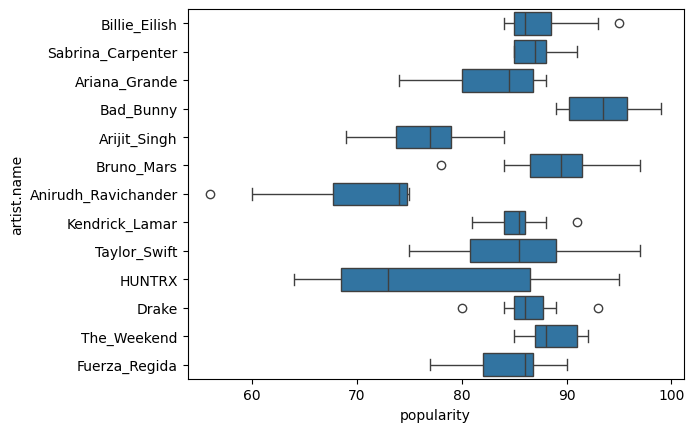

In [7]:
gather_tracks_2.popularity.sort_values()
sns.boxplot(data = gather_tracks_2, x="popularity", y = "artist.name")

<Axes: xlabel='duration_ms', ylabel='artist.name'>

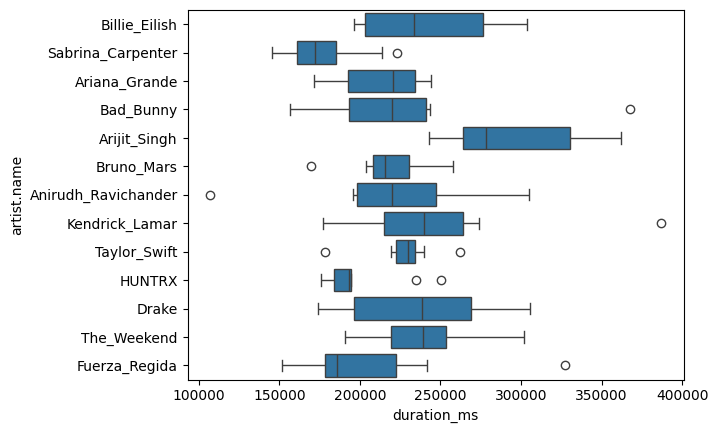

In [8]:
sns.boxplot(data = gather_tracks_2, x="duration_ms", y = "artist.name")

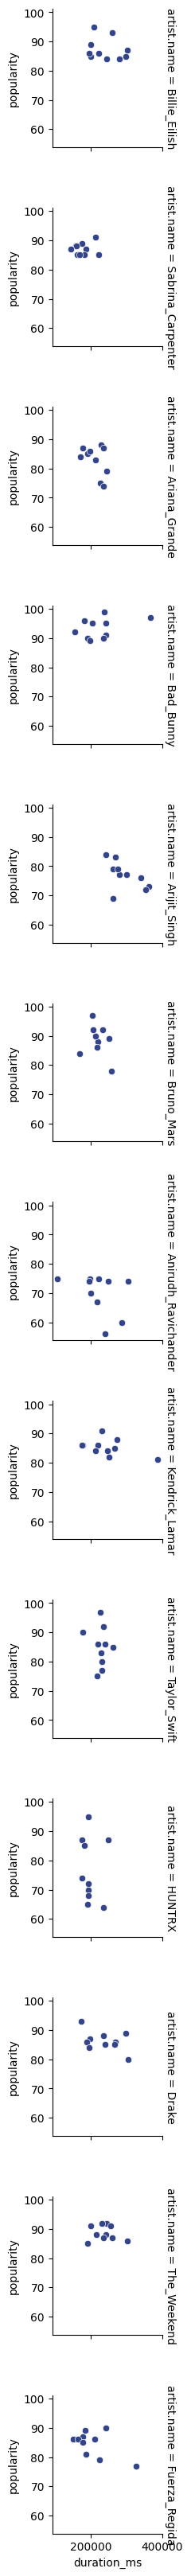

In [19]:
#plt.subplots(figsize=(12,9))
g = sns.FacetGrid(gather_tracks_2, row="artist.name", margin_titles=True, height=2.5)
#sns.scatterplot(data=gather_tracks_2, x="duration_ms", y="popularity", hue="artist.name")
g.map(sns.scatterplot, "duration_ms", "popularity", color="#334488")

In [6]:
gather_tracks_2.duration_ms.sort_values()

63     107036
15     145398
124    151836
35     156364
13     157279
        ...  
44     341054
47     354051
40     362400
31     367725
73     386906
Name: duration_ms, Length: 130, dtype: int64

In [ ]:
gather_tracks_2

/tmp/ipykernel_5303/421574204.py:4: MatplotlibDeprecationWarning: Passing label as a length 13 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(xpoints, ypoints, label = gather_tracks_2["artist.name"].unique())


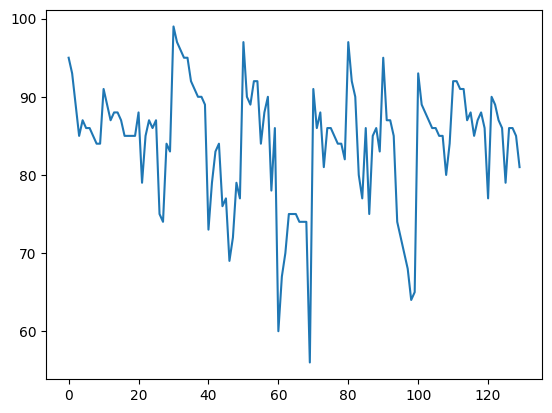

In [23]:
xpoints = gather_tracks_2.index
ypoints = gather_tracks_2.popularity

plt.plot(xpoints, ypoints, label = gather_tracks_2["artist.name"].unique())
plt.show()

In [21]:
gather_tracks_2["artist.name"].unique()

AttributeError: 'ArrowStringArray' object has no attribute 'to_list'

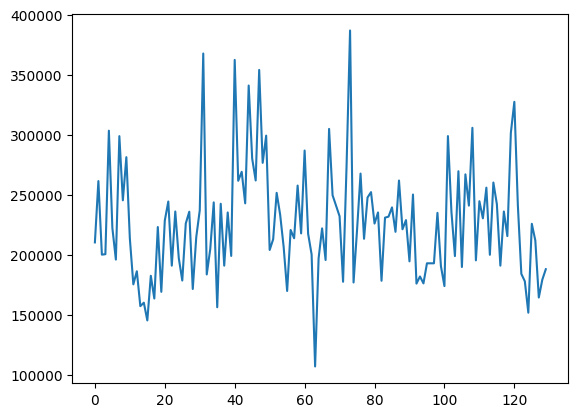

In [13]:
xpoints = gather_tracks_2.index
ypoints = gather_tracks_2.duration_ms

plt.plot(xpoints, ypoints)
plt.show()

<Axes: xlabel='index', ylabel='popularity'>

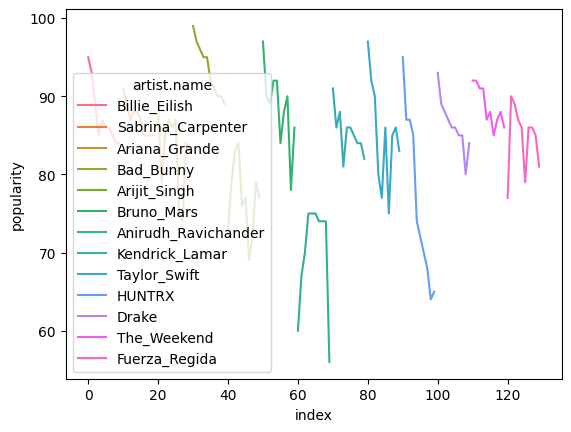

In [28]:
sns.lineplot(data=gather_tracks_2.reset_index(),x='index',  y='popularity', hue='artist.name')

# Renommer les fichiers dont le nom ne correspondent pas au format

In [33]:
def fetch_list_of_file():
    
    # On affiche le chemin
    print(os.getcwd())
    # On change le répertoire en cours
    os.chdir('/home/kesav/airflow_project/raw/spotify/artist/')
    # On affiche le chemin pour vérifier le changement
    print(os.getcwd())
    # On crée une liste vide
    name_file_to_analyze = []
    # On récupère tous les fichiers qui contiennent 2026 dans le répertoire Spotify
    with os.scandir(".") as d:
        for e in d:
            name_file_to_analyze.append(e.name)
    return name_file_to_analyze
    

In [30]:
path = '/home/kesav/airflow_project/raw/spotify/artist/test/'
name_file_to_analyze = fetch_list_of_file()
"""for i in name_file_to_analyze:
    print(i)
    x = re.findall(r'(.*)_(\d{4}-\d{2}-\d{2}).json$', i)
    print(x)"""
    
    
#i = "top_tracks_Sabrina_Carpenter_2025-12-15.json"

#x = re.findall(r'(.*)_(\d{4}-\d{2}-\d{2}).json$', i)


#print(path+x[0][1]+"_"+x[0][0]+".json")

#source = path + i

#dest = path+x[0][1]+"_"+x[0][0]+".json"

#print(source)

#os.rename(source, dest)

for i in name_file_to_analyze:
    source = path + i
    x = re.findall(r'(.*)_(\d{4}-\d{2}-\d{2}).json$', i)
    dest = path+x[0][1]+"_"+x[0][0]+".json"
    os.rename(source, dest)


#https://regex101.com/
#/.+_(\d{4}-\d{2}-\d{2}).json$/gm
#r'(.*)_(\d{4}-\d{2}-\d{2}).json$'


/home/kesav/airflow_project/raw/spotify/artist
/home/kesav/airflow_project/raw/spotify/artist/test


<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2869/142427936.py:3: SyntaxWarning: invalid escape sequence '\d'
  """for i in name_file_to_analyze:


In [40]:
path = '/home/kesav/airflow_project/raw/spotify/artist/'
name_file_to_analyze = fetch_list_of_file()

for i in name_file_to_analyze:
    source = path + i
    x = re.findall(r'.+_(\d{4}-\d{2}-\d{2}).json$', i)
    #print(source)
    if not x:
        print('empty')
    else:
        os.remove(source)
    #os.rename(source, dest)




/home/kesav/airflow_project/raw/spotify/artist
/home/kesav/airflow_project/raw/spotify/artist
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty
empty


In [8]:
conn = psycopg2.connect(database = "project_spotify_db", 
                        user = "postgres", 
                        host= 'localhost',
                        password = "example",
                        port = 5432)

print(str(conn.status))

1
